In [1]:
from Bio import SeqIO
from Bio import Phylo
from Bio.SeqRecord import SeqRecord
from Bio.Align import MultipleSeqAlignment
from Bio.Phylo.TreeConstruction import DistanceCalculator
from Bio.Phylo.TreeConstruction import DistanceTreeConstructor
import matplotlib.pyplot as plt

# Charger les séquences du fichiers FASTA

In [2]:
for seq_record in SeqIO.parse(open("GCA_000151905.3_gorGor4_genomic.fna",mode='r'),'fasta'):
    p1=seq_record.seq
    break
len(p1)

228908639

In [3]:
for seq_record in SeqIO.parse(open("GCA_001723895.1_CroPor_comp1_genomic.fna",mode='r'),'fasta'):
    p2=seq_record.seq
    break
len(p2)

270692262

In [4]:
for seq_record in SeqIO.parse(open("GCA_965152235.1_rEreImb1.hap1_genomic.fna",mode='r'),'fasta'):
    p3=seq_record.seq
    break
len(p3)

361961700

In [5]:
for seq_record in SeqIO.parse(open("GCA_008658375.2_mBalMus1.alt.v2_genomic.fna",mode='r'),'fasta'):
    p4=seq_record.seq
    break
len(p4)

1561877

In [6]:
for seq_record in SeqIO.parse(open("GCA_004027065.2_HipAmp_v2_BIUU_UCD_genomic.fna",mode='r'),'fasta'):
    p5=seq_record.seq
    break
len(p5)

1854880

In [8]:
for seq_record in SeqIO.parse(open("GCA_017591445.1_ASM1759144v1_genomic.fna",mode='r'),'fasta'):
    p6=seq_record.seq
    break
len(p6)

210919050

# Réaliser l'alignement

In [9]:
align1 = MultipleSeqAlignment([SeqRecord(p1[0:1561877],id="Gorille"), 
SeqRecord(p2[0:1561877], id="Whale"),
SeqRecord(p3[0:1561877], id="Froq"),
SeqRecord(p4[0:1561877], id="Fish"),
SeqRecord(p5[0:1561877], id="Hippo"),
SeqRecord(p6[0:1561877], id="ASM"),                        
])

# Afficher les régions d'alignements

In [10]:
print(align1)

Alignment with 6 rows and 1561877 columns
CTACCAAAAGGCTAGCTAATAAAGCAAGAATATCTTAGTGCTCC...cca Gorille
agatcagaaggcaatattttacagttagggtggccaaaatctgg...CAA Whale
tccctaaccctaacccctaaccctaaccctaaccctaaccaccc...GCt Froq
TTCAGGCGGTGATGAAAGCGAGCGATGGGGcgctgcagatgaag...TGA Fish
acaccagtcagaatggccatcatcacaaaatctggaaaccacaa...TTG Hippo
AGAGGGGGATGTTGACCAGGCCCCTGTGATGGTCAGACGTCCCA...TTT ASM


In [11]:
# Calculating Distance
calculator = DistanceCalculator('identity')
# Generating Distance Matrix
distance_matrix = calculator.get_distance(align1)

In [12]:
# Print Distance Matrix
print("************Distance Matrix**********")
print(distance_matrix)

************Distance Matrix**********
Gorille 0.000000
Whale   0.885374    0.000000
Froq    0.898263    0.894175    0.000000
Fish    0.893668    0.858535    0.894413    0.000000
Hippo   0.885914    0.855705    0.896460    0.855148    0.000000
ASM 0.892194    0.856943    0.892047    0.856993    0.854969    0.000000
    Gorille Whale   Froq    Fish    Hippo   ASM


# Construction de l'arbre phylogenétique en utilisant l'algorithme UPGMA

In [13]:
constructor = DistanceTreeConstructor()
UPGMATree = constructor.upgma(distance_matrix)

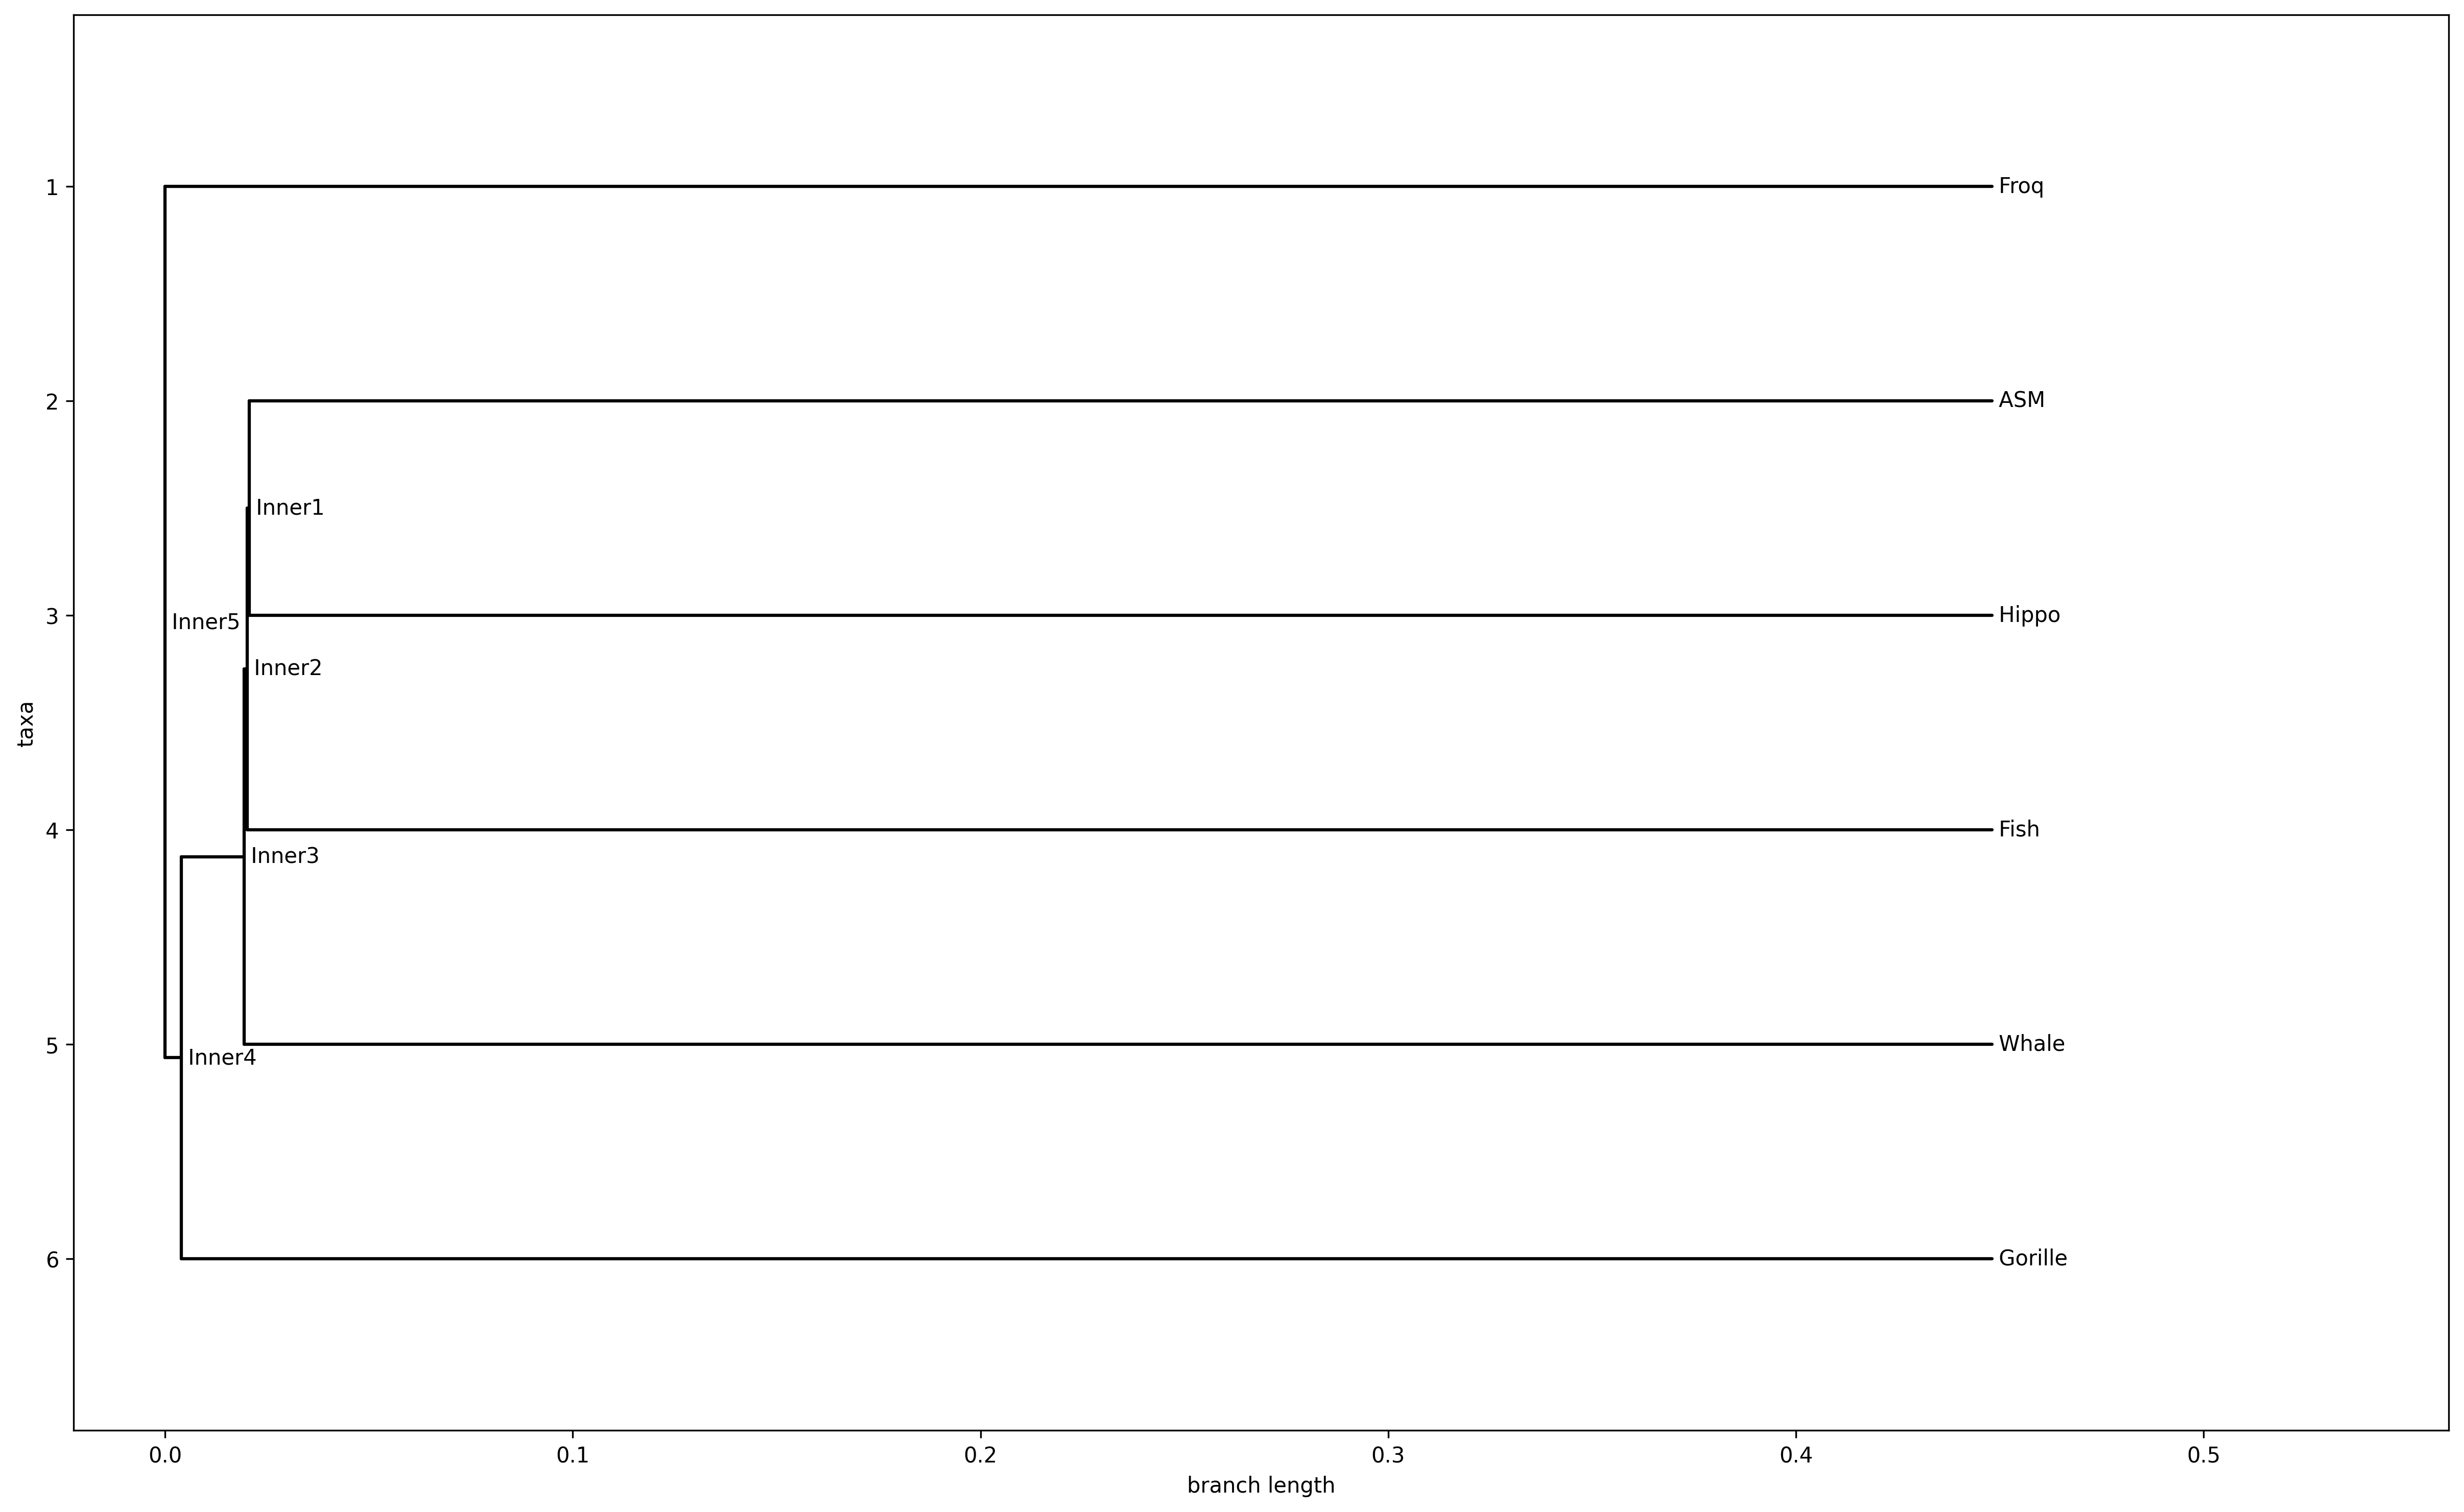

In [14]:
fig = plt.figure(figsize=(20, 12), dpi=300) 
#matplotlib.rc('font', size=10)
#matplotlib.rc('xtick', labelsize=12) # fontsize of the tick labels at x axis
#matplotlib.rc('ytick', labelsize=12) # fontsize of the tick labels at y axis
axes = fig.add_subplot(1, 1, 1)

Phylo.draw(UPGMATree, axes=axes)
plt.show()